### HuyIGW04 - MLP for Sentiment Classification

In [ ]:
# download data and unzip
!gdown --quiet 1GaTMURqIQTjtalbNVAyVgPIEis21A0r8 
!python -m zipfile -e .\FER-2013.zip .\FER-2013

In [12]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Resize
from torchvision.io import read_image                   # convert image to torch
from sklearn.model_selection import train_test_split

In [13]:
# link
train_dir = './FER-2013/train'
test_dis = './FER-2013/test'
# label
classes = os.listdir(train_dir)
label2idx = {y:x for x, y in enumerate(classes)}
idx2label = {x:y for x, y in enumerate(classes)}

print(classes)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [14]:
# manual seed
random_seed = 10
np.random.seed(random_seed)
if torch.cuda.is_available():
    torch.manual_seed(random_seed)

# device 
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [15]:
# build inheritance class from Dataset
class CustomDataset(Dataset):
    def __init__(self, set_path, class2label, split='train', norm=True, val_size=0.2):
        super().__init__()
        self.set_path = set_path
        self.class2label = class2label
        self.norm = norm
        self.val_size = val_size
        self.split = split
        self.path_list, self.label_list = self.path_to_list()
        self.resize = Resize(size=(128, 128))

        # split valid and train
        if self.split in ['train', 'val'] and 'train' in set_path.lower():
            train_set, val_set = train_test_split(list(zip(self.path_list, self.label_list)),
                                                  random_state=random_seed,
                                                  test_size=val_size,
                                                  stratify=self.label_list)
            
            if self.split == 'train':
                self.path_list, self.label_list = zip(*train_set)       # unzip
            elif self.split == 'val':
                self.path_list, self.label_list = zip(*val_set)
        
    
    # get link, analyze all imgs to path_img_list and label_list
    def path_to_list(self):
        path_list = []
        label_list = []
        for element in classes:
            for img in os.listdir(os.path.join(self.set_path, element)):
                img_path = os.path.join(self.set_path, element, img)
                path_list.append(img_path)
                label_list.append(element)
        
        return path_list, label_list

    def __len__(self):
        return len(self.label_list)
    
    # return x by matrix shape (torch, float32), y by (torch, long)
    def __getitem__(self, index):
        # convert img to tensor
        img_path = self.path_list[index]
        sample_img_tensor = self.resize(read_image(img_path))
        sample_img_tensor = sample_img_tensor.type(torch.float32)

        # convert label from string to long tensor
        cls = self.label_list[index]
        label = self.class2label[cls]
        
        # normalization [-1, 1]
        if self.norm:
            sample_img_tensor = (sample_img_tensor/127.5) - 1

        return sample_img_tensor, label


In [16]:
# Dataset
train = CustomDataset(train_dir, 
                      class2label=label2idx,
                      split='train',
                      norm=True)
val = CustomDataset(train_dir, 
                      class2label=label2idx,
                      split='val',
                      norm=True)
test = CustomDataset(train_dir, 
                      class2label=label2idx,
                      split='test',
                      norm=True)


# DataLoader
train_set = DataLoader(train,
                       batch_size=512,
                       shuffle=True)

val_set = DataLoader(val,
                    batch_size=256,
                    shuffle=True)

test_set = DataLoader(test,
                      batch_size=256,
                      shuffle=True)


In [17]:
# model construction
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear1 = nn.Linear(input_dim, 512)
        self.linear2 = nn.Linear(512, 256)
        self.linear3 = nn.Linear(256, 64)
        self.output = nn.Linear(64, output_dim)
    
    def forward(self, x):
        x = nn.Flatten()(x)
        x = self.linear1(x)
        F.relu(x)
        x = self.linear2(x)
        F.relu(x)
        x = self.linear3(x)
        F.relu(x)
        output = self.output(x)
        return output

# read a sample to get input_dim
PATH = os.path.join(train_dir, 'angry', 'Training_3908.jpg')
img = read_image(PATH)
resize = Resize((128, 128))
img = resize(img)
img = img.type(torch.float32)
img = img.reshape(1, -1)
input_dim = img.shape[1]
output_dim = len(classes)
model = MLP(input_dim, output_dim).to(device)

In [18]:
# optimizer and criterion
lr = 1e-1
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [19]:
# evaluation
def accuracy_eval(y_pred: torch.Tensor, y_true: torch.Tensor):
    y_pred = y_pred.to(device)
    y_true = y_true.to(device)
    y_true_label = torch.argmax(y_pred, dim=1)
    true_pred = torch.sum(y_true_label == y_true).item()
    acc = true_pred/len(y_true)
    return acc

# test evaluation function
for _, (X_train, y_train) in enumerate(train_set):
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    y_hat_ex = model(X_train)
    print(accuracy_eval(y_hat_ex, y_train))
    break    

0.25390625


In [20]:
# training
epochs = 50
train_losses = []
val_losses = []
train_acc = []
val_acc = []

for epoch in range(epochs):
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_train_acc = []
    epoch_val_acc = []

    model.train()
    for _, (X_train_batch, y_train_batch) in enumerate(train_set):
        X_train_batch = X_train_batch.to(device)
        y_train_batch = y_train_batch.to(device)
        y_train_hat = model(X_train_batch)
        optimizer.zero_grad()
        train_loss_batch = criterion(y_train_hat, y_train_batch)
        train_loss_batch.backward()
        optimizer.step()

        epoch_train_losses.append(train_loss_batch.item())
        acc_train_batch = accuracy_eval(y_train_hat, y_train_batch)
        epoch_train_acc.append(acc_train_batch)        
    
    model.eval()
    with torch.no_grad():
        epoch_train_loss = sum(epoch_train_losses)/len(epoch_train_losses)
        train_losses.append(epoch_train_loss)
        
        epoch_train_acc = sum(epoch_train_acc)/len(epoch_train_acc)
        train_acc.append(epoch_train_acc)

        # validation
        for _, (X_train_val, y_train_val) in enumerate(val_set):
            X_train_val = X_train_val.to(device)
            y_train_val = y_train_val.to(device)
            y_val_hat = model(X_train_val)
            
            loss_val_batch = criterion(y_val_hat, y_train_val)
            epoch_val_losses.append(loss_val_batch.item())
            
            acc_val_batch = accuracy_eval(y_val_hat, y_train_val)
            epoch_val_acc.append(acc_val_batch)
        
        val_loss = sum(epoch_val_losses)/len(epoch_val_losses)
        val_losses.append(val_loss)

        val_acc_value = sum(epoch_val_acc)/len(epoch_val_acc)
        val_acc.append(val_acc_value)
    
    # for debug
    print(f'EPOCH {epoch + 1}:   train_loss = {epoch_train_loss},   val_loss = {val_loss},   train_acc = {round(epoch_train_acc, 3)},     val_acc = {round(val_acc_value, 3)}  ')



EPOCH 1:   train_loss = 1.7649567630555896,   val_loss = 1.6976293377254321,   train_acc = 0.3,     val_acc = 0.33  
EPOCH 2:   train_loss = 1.681984445783827,   val_loss = 1.661390729572462,   train_acc = 0.345,     val_acc = 0.35  
EPOCH 3:   train_loss = 1.6577818181779649,   val_loss = 1.6653445596280305,   train_acc = 0.355,     val_acc = 0.345  
EPOCH 4:   train_loss = 1.6358013179567126,   val_loss = 1.6495804994002632,   train_acc = 0.369,     val_acc = 0.352  
EPOCH 5:   train_loss = 1.628234158621894,   val_loss = 1.6681621333827144,   train_acc = 0.372,     val_acc = 0.346  
EPOCH 6:   train_loss = 1.620121537314521,   val_loss = 1.6386217604512754,   train_acc = 0.374,     val_acc = 0.36  
EPOCH 7:   train_loss = 1.612469866540697,   val_loss = 1.6420924145242441,   train_acc = 0.379,     val_acc = 0.362  
EPOCH 8:   train_loss = 1.6066953420639039,   val_loss = 1.6344746247581814,   train_acc = 0.381,     val_acc = 0.363  
EPOCH 9:   train_loss = 1.6021235545476278,   val_

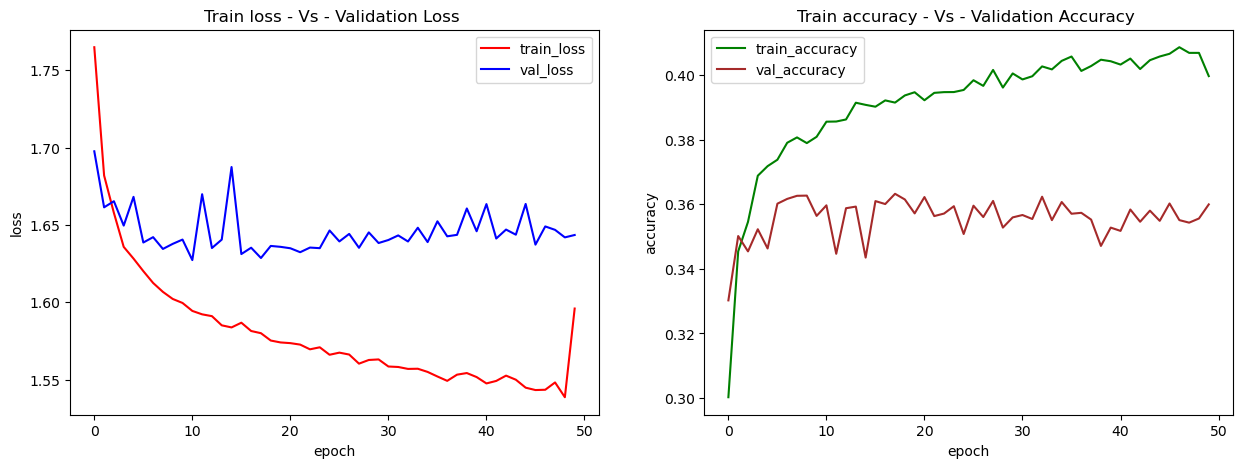

In [21]:
_, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].set_title('Train loss - Vs - Validation Loss ')
ax[0].plot(train_losses, color='red', label='train_loss')
ax[0].plot(val_losses, color='blue', label='val_loss')
ax[0].set(xlabel='epoch', ylabel='loss')
ax[0].legend()


ax[1].set_title('Train accuracy - Vs - Validation Accuracy ')
ax[1].plot(train_acc, color='green', label='train_accuracy')
ax[1].plot(val_acc, color='brown', label='val_accuracy')
ax[1].set(xlabel='epoch', ylabel='accuracy')
ax[1].legend()

plt.show()

In [22]:
# evaluation
test_acc = []
for _, (X_test_batch, y_test_batch) in enumerate(test_set):
    X_test_batch = X_test_batch.to(device)
    y_test_batch = y_test_batch.to(device)
    y_hat_test = model(X_test_batch)
    acc = accuracy_eval(y_hat_test, y_test_batch)
    test_acc.append(acc)

metric = sum(test_acc)/len(test_acc)
print('Accuracy of test set: {}'.format(round(metric, 4)))

Accuracy of test set: 0.4015
